# E-Commerce Sales Analysis

## Executive Summary

This project analyzes e-commerce sales data to uncover key business insights related to revenue, profitability, customer behavior, product performance, and regional trends. Using Python, SQL, and Power BI, the analysis identifies sales drivers, evaluates discount impact on profit, and provides data-driven recommendations to support business growth and decision-making.

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Sample - Superstore.csv", encoding = "latin-1")

## Dataset Information

In [86]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
data.shape

(9994, 21)

In [6]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## Data Cleaning & Preprocessing

In [7]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

## Feature Engineering

In [9]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [11]:
data['Year'] = data['Order Date'].dt.year

In [12]:
data['Month'] = data['Order Date'].dt.month

In [13]:
data['Shipping Days'] = (data['Ship Date'] - data['Order Date']).dt.days

In [14]:
data[['Order Date','Ship Date','Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


## KPI Analysis

# Total Sales

In [15]:
data['Sales'].sum()

np.float64(2297200.8603)

# Total Profit

In [16]:
data['Profit'].sum()

np.float64(286397.0217)

# Total Orders

In [17]:
data['Order ID'].nunique()

5009

# Total Customers

In [18]:
data['Customer ID'].nunique()

793

# Yearly Sales Trend Analysis

In [19]:
yearly_sales = data.groupby('Year')['Sales'].sum()

In [20]:
yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

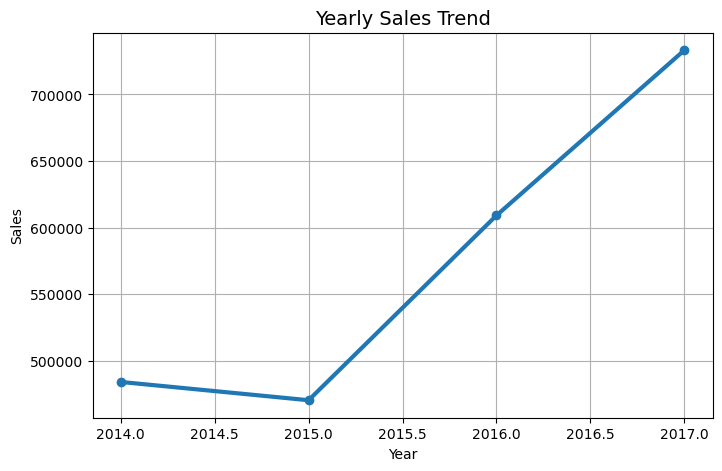

In [21]:
plt.figure(figsize=(8,5))

yearly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title("Yearly Sales Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

# Monthly Sales Trend Analysis

In [22]:
monthly_sales = data.groupby('Month')['Sales'].sum()

In [23]:
monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

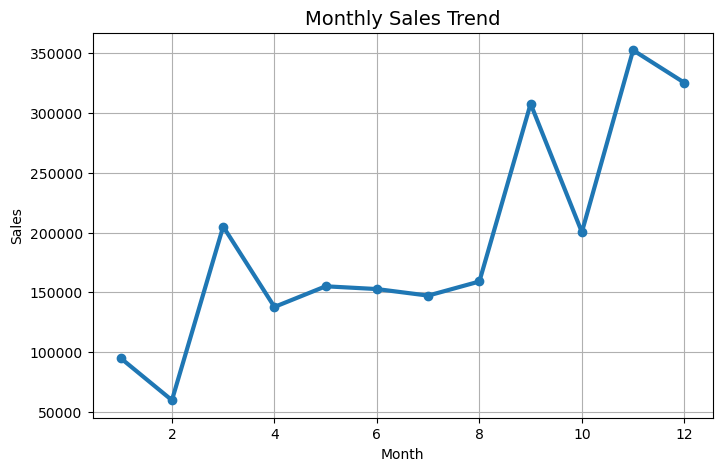

In [24]:
plt.figure(figsize=(8,5))

monthly_sales.plot(
    marker='o',
    linewidth=3
)

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

# 
Category Analysis

In [25]:
data.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

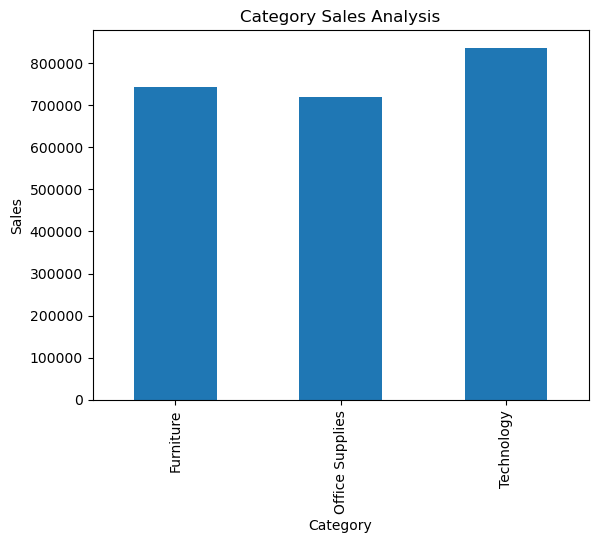

In [26]:
data.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Category Sales Analysis')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

# Sub-Category Sales Analysis

In [27]:
sub_Sales = data.groupby('Sub-Category')['Sales'].sum()

In [28]:
sub_Sales

Sub-Category
Accessories    167380.3180
Appliances     107532.1610
Art             27118.7920
Binders        203412.7330
Bookcases      114879.9963
Chairs         328449.1030
Copiers        149528.0300
Envelopes       16476.4020
Fasteners        3024.2800
Furnishings     91705.1640
Labels          12486.3120
Machines       189238.6310
Paper           78479.2060
Phones         330007.0540
Storage        223843.6080
Supplies        46673.5380
Tables         206965.5320
Name: Sales, dtype: float64

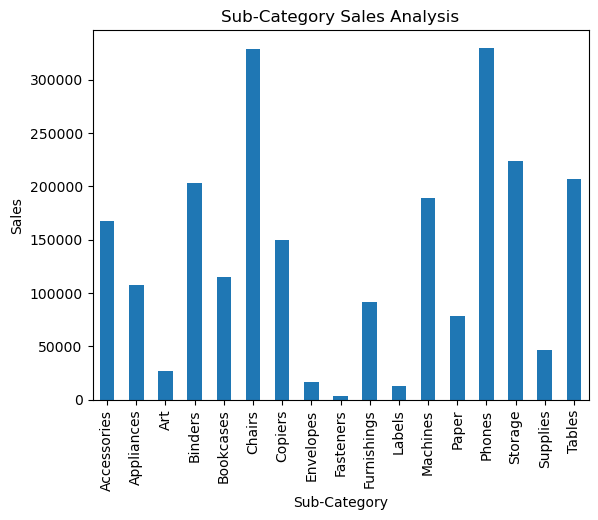

In [29]:
sub_Sales = data.groupby('Sub-Category')['Sales'].sum().plot(kind='bar')
plt.title('Sub-Category Sales Analysis')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.show()

# Yearly Profit Analysis

In [30]:
yearly_profit = data.groupby('Year')['Profit'].sum()

In [31]:
yearly_profit

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

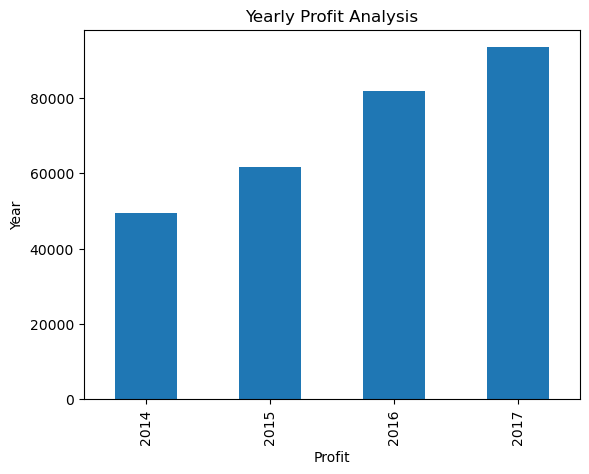

In [32]:
yearly_profit = data.groupby('Year')['Profit'].sum().plot(kind='bar')
plt.title('Yearly Profit Analysis')
plt.xlabel('Profit')
plt.ylabel('Year')
plt.show()

# Monthly Profit Analysis

In [33]:
monthly_Profit = data.groupby('Month')['Profit'].sum()

In [34]:
monthly_Profit

Month
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64

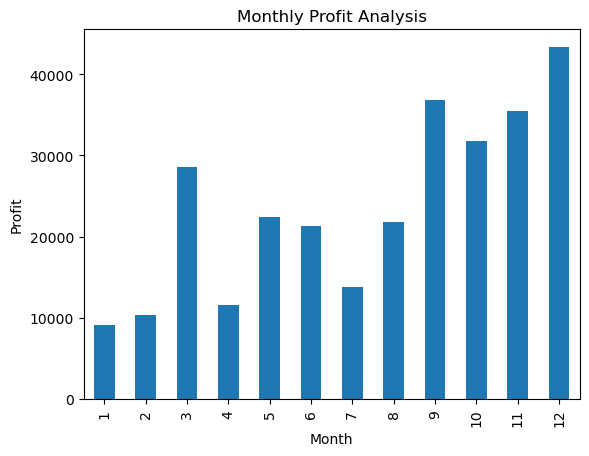

In [35]:
monthly_Profit = data.groupby('Month')['Profit'].sum().plot(kind='bar')
plt.title('Monthly Profit Analysis')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()

# Category Profit Analysis

In [36]:
cat_profit = data.groupby('Category')['Profit'].sum()

In [37]:
cat_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

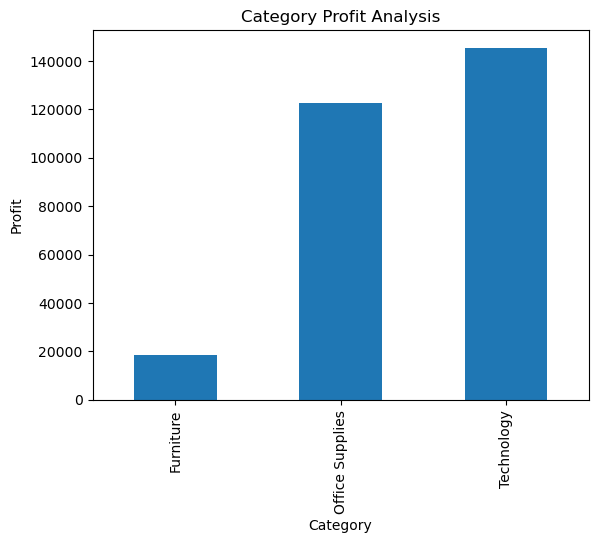

In [38]:
cat_profit = data.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Category Profit Analysis')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

# Region Sales Analysis

In [39]:
region_sales = data.groupby('Region')['Sales'].sum()

In [40]:
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

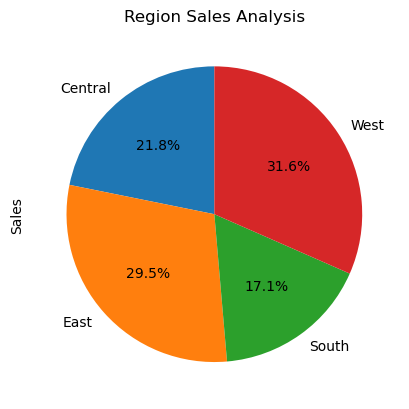

In [41]:
region_sales = data.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Region Sales Analysis')
plt.show()

# Region Profit Analysis

In [42]:
region_profit = data.groupby('Region')['Profit'].sum()

In [43]:
region_profit

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

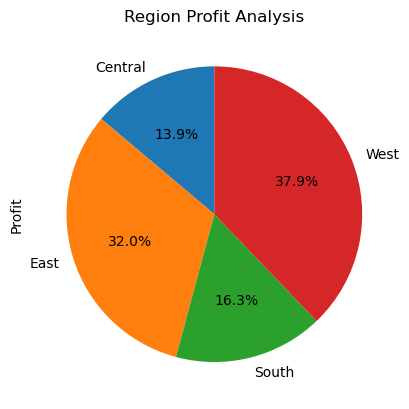

In [44]:
region_profit = data.groupby('Region')['Profit'].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Region Profit Analysis')
plt.show()

# State Analysis

# Top 10 States With Highest Sales

In [49]:
state_sales = data.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

In [50]:
state_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

# Top 10 States With Loss

In [53]:
state_loss = data.groupby('State')['Profit'].sum().sort_values().head(10)

In [54]:
state_loss

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

# Customer Analysis

In [55]:
cust_sales = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [56]:
cust_sales

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [57]:
cust_profit = data.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

In [58]:
cust_profit

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

# Segment Analysis

In [59]:
Segment_sales = data.groupby('Segment')['Sales'].sum()

In [60]:
Segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

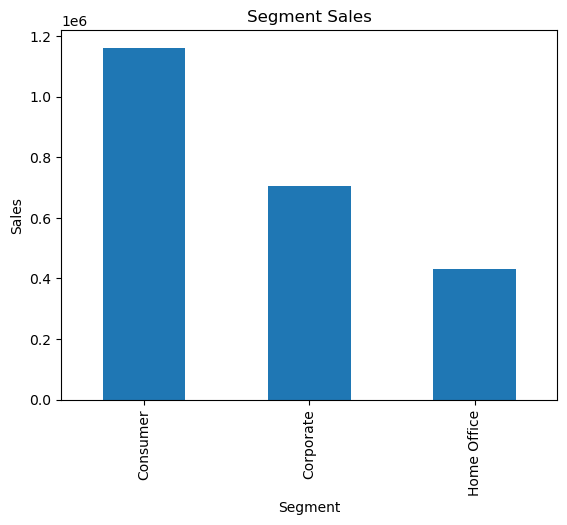

In [61]:
Segment_sales = data.groupby('Segment')['Sales'].sum().plot(kind='bar')
plt.title('Segment Sales')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.show()

# Discount Analysis

# Average Discount

In [62]:
avg_discount = data['Discount'].mean()

In [63]:
avg_discount

np.float64(0.1562027216329798)

# Discount Vs Profit

In [64]:
data.groupby('Discount')['Profit'].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

# Correlation

In [66]:
data[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


# Shipping Analysis

# Average Shipping Days

In [67]:
data['Shipping Days'].mean()

np.float64(3.958174904942966)

# Ship Mode Analysis

# Sales by Shipping Days

In [68]:
data.groupby('Shipping Days')['Sales'].sum()

Shipping Days
0    124907.6910
1     67975.3312
2    368465.8300
3    204659.5988
4    631847.0053
5    494357.0837
6    240290.5698
7    164697.7505
Name: Sales, dtype: float64

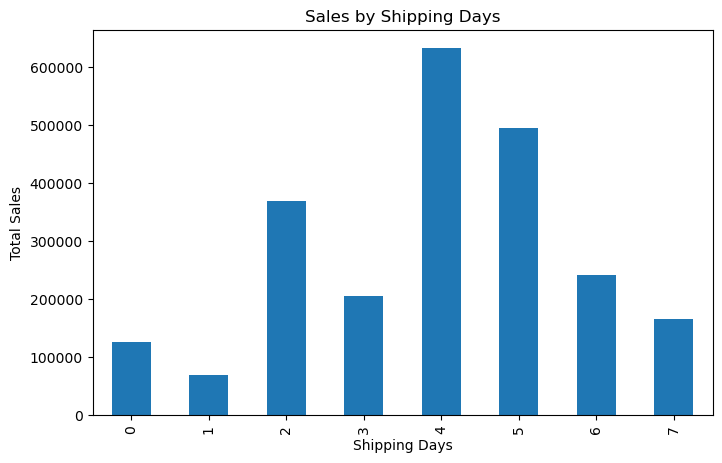

In [69]:
ship_sales = data.groupby('Shipping Days')['Sales'].sum()

ship_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Shipping Days')
plt.xlabel('Shipping Days')
plt.ylabel('Total Sales')
plt.show()

# Average Profit by Shipping Days

In [71]:
ship_profit = data.groupby('Shipping Days')['Profit'].mean()

In [72]:
ship_profit

Shipping Days
0    29.645411
1    20.436929
2    39.818676
3    26.742208
4    25.643394
5    27.078471
6    27.660821
7    32.740494
Name: Profit, dtype: float64

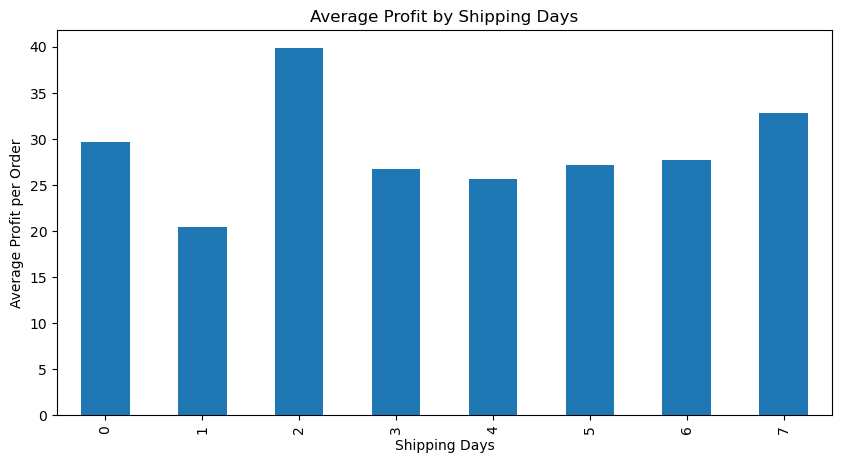

In [73]:
ship_profit = data.groupby('Shipping Days')['Profit'].mean()

ship_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Profit by Shipping Days')
plt.xlabel('Shipping Days')
plt.ylabel('Average Profit per Order')
plt.show()

# Top Products

In [74]:
top_products = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [75]:
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

# Most Profitable Products

In [77]:
data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

# Loss Making Products

In [78]:
data.groupby('Product Name')['Profit'].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

# Correlation Analysis

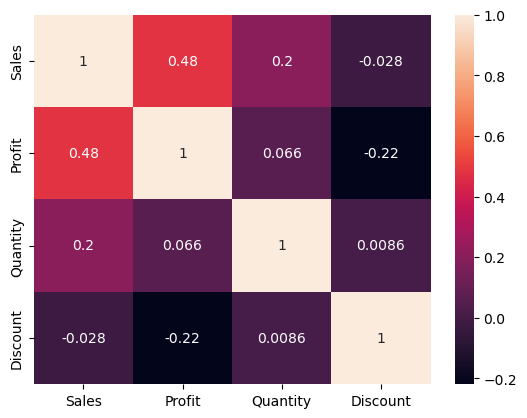

In [83]:
sns.heatmap(
    data[['Sales','Profit','Quantity','Discount']].corr(),
    annot=True
)
plt.show()

## Key Business Insights

1. Technology emerged as the highest revenue-generating product category.

2. Higher discount levels showed a negative impact on overall profitability.

3. The Consumer segment contributed the largest share of total sales revenue.

4. Standard Class was the most preferred shipping mode among customers.

5. A small group of high-value customers contributed a significant portion of total revenue.

## Recommendations

1. Optimize discount strategies.

2. Focus on high-value customers.

3. Improve inventory planning for top-selling categories.

4. Monitor low-profit products and regions.

## Conclusion

The analysis successfully identified key revenue drivers, customer purchasing patterns, profitability factors, and operational trends. These insights can help businesses optimize pricing strategies, improve customer retention, enhance inventory planning, and support data-driven decision-making.